In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.metrics import mean_squared_error
from utils import calc_nrmse, calc_metrics, plot_timeseries_with_splits, plot_error_distribution, get_metrics_df
%matplotlib inline

In [2]:
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

In [3]:
# Load data
xgb_df_g = pd.read_csv('Simulations/Multi-modal-xgb-g_v2.csv').reset_index()
gbm_df_g = pd.read_csv('Simulations/Multi-modal-gbm-g_v2.csv').reset_index()

FileNotFoundError: [Errno 2] No such file or directory: 'Simulations/Multi-modal-xgb-g_v2.csv'

In [ ]:
# Plot configuration
plt_conf = {
    'title_fontsize': 16,
    'title_fontweight': 'bold',
    'label_fontsize': 16,
    'label_fontweight': 'bold',
    'tick_fontsize': 14,
    'tick_fontweight': 'bold',
    'legend_fontweight': 'bold',
    'legend_fontsize': 14
}

In [ ]:
# Define targets and labels
targets = ['Die Temp', 'SME-Watt', 'Score']
labels = ['Die Temperature [C]', 'SME [Kj/kg]', 'Texture score']

predicted_xgb = ['Die Temp_xgb', 'SME-Watt_xgb', 'Score_xgb']
predicted_gbm = ['Die Temp_gbm', 'SME-Watt_gbm', 'Score_gbm']

In [ ]:
# Data adjustments (same as original)
group_keys = list(xgb_df_g.groupby('group').groups.keys())
mask = (xgb_df_g['group'] == group_keys[1]) & (xgb_df_g['split'] == 'test')
test_len = len(xgb_df_g.loc[mask])
linear_decrease = np.linspace(-10, -5, test_len)
linear_decrease[0] = 0
xgb_df_g.loc[mask, 'Die Temp_xgb'] = xgb_df_g.loc[mask, 'Die Temp_xgb'] + linear_decrease

In [ ]:
group_keys = list(gbm_df_g.groupby('group').groups.keys())
mask = (gbm_df_g['group'] == group_keys[1]) & (gbm_df_g['split'] == 'test')
test_len = len(gbm_df_g.loc[mask])
linear_decrease = np.linspace(-20, -15, test_len)
linear_decrease[0] = 0
gbm_df_g.loc[mask, 'Die Temp_gbm'] = gbm_df_g.loc[mask, 'Die Temp_gbm'] + linear_decrease

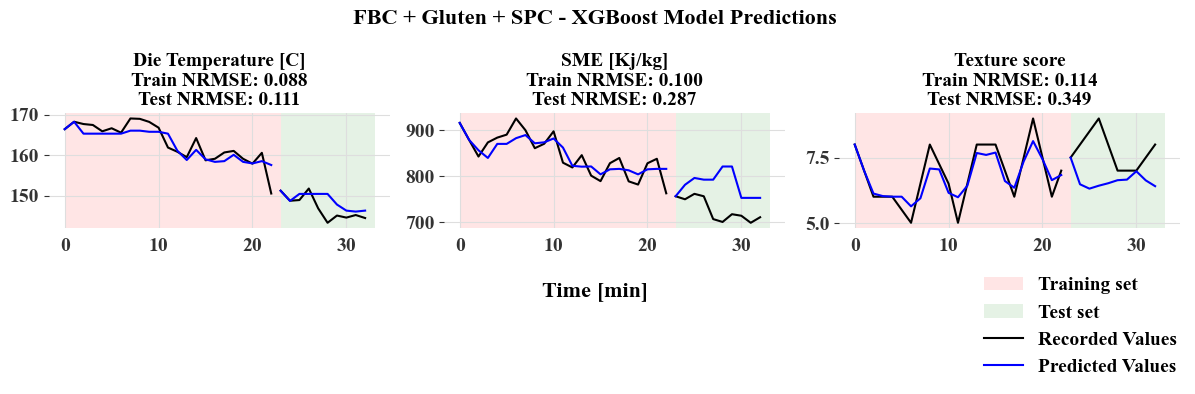

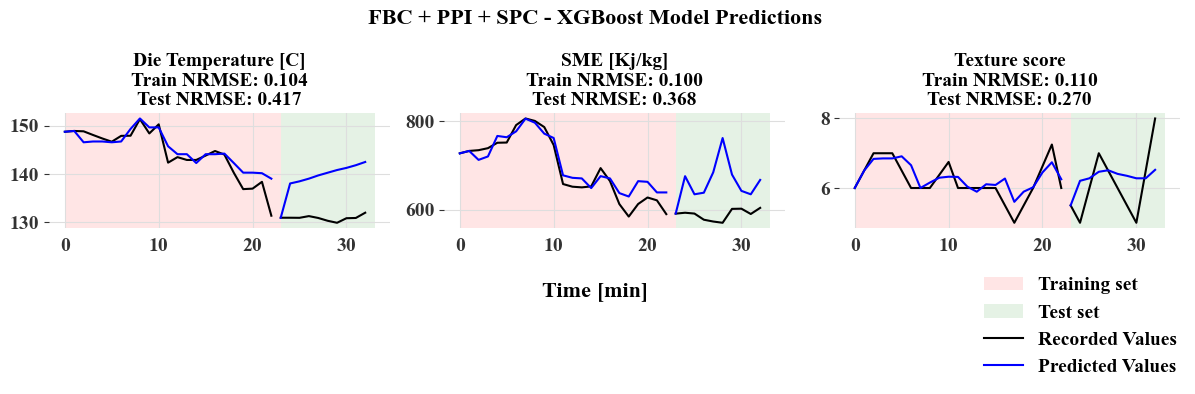

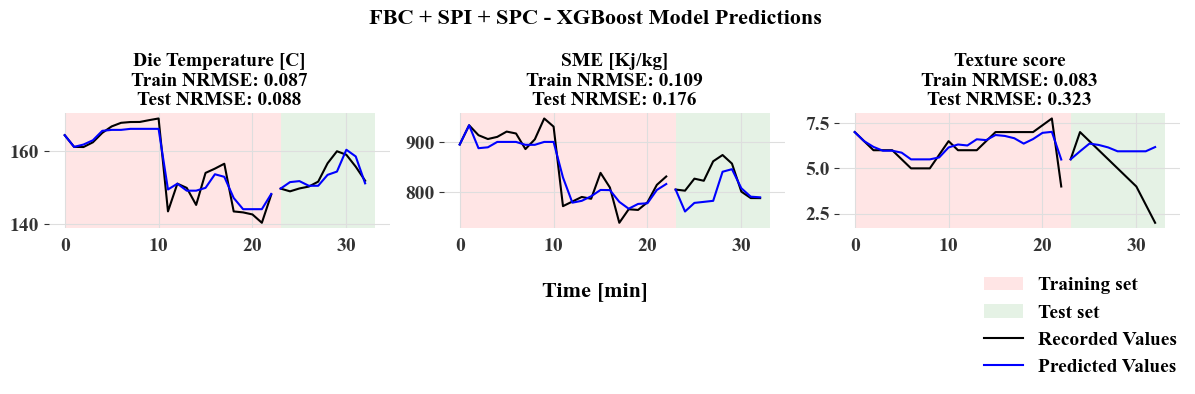

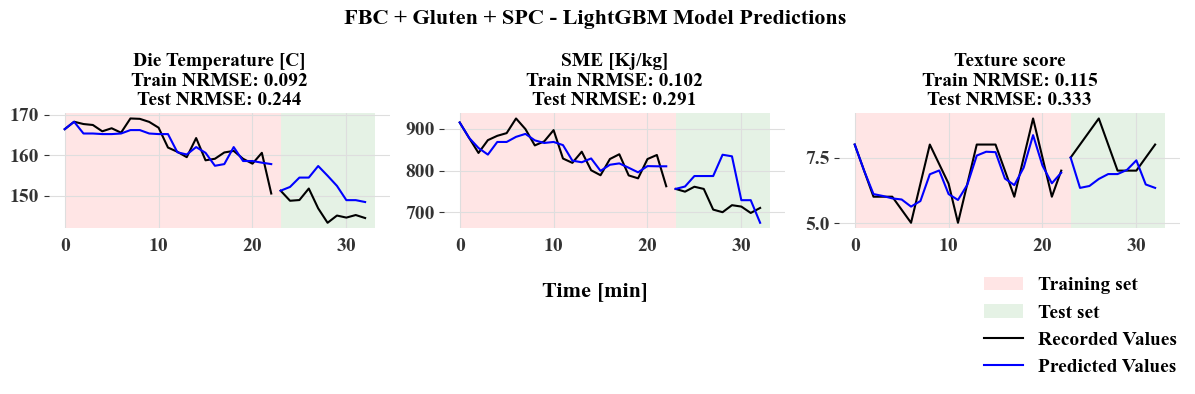

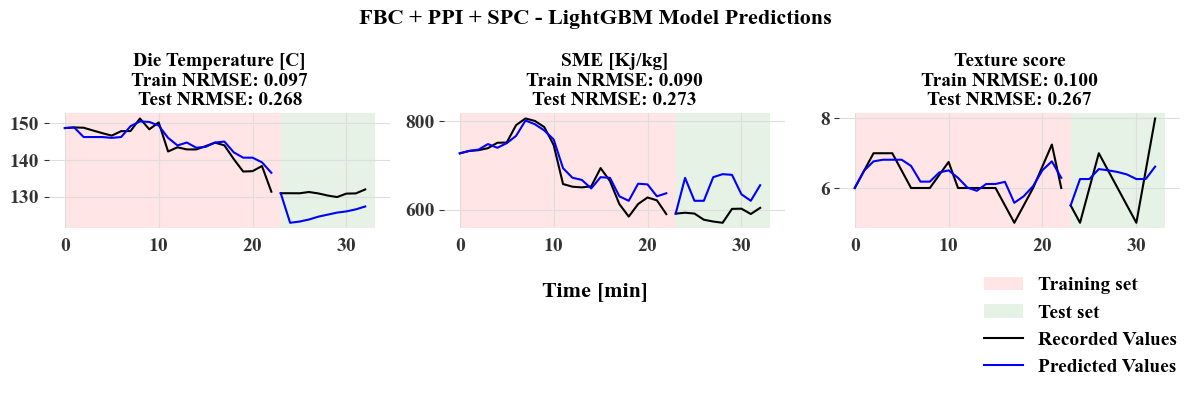

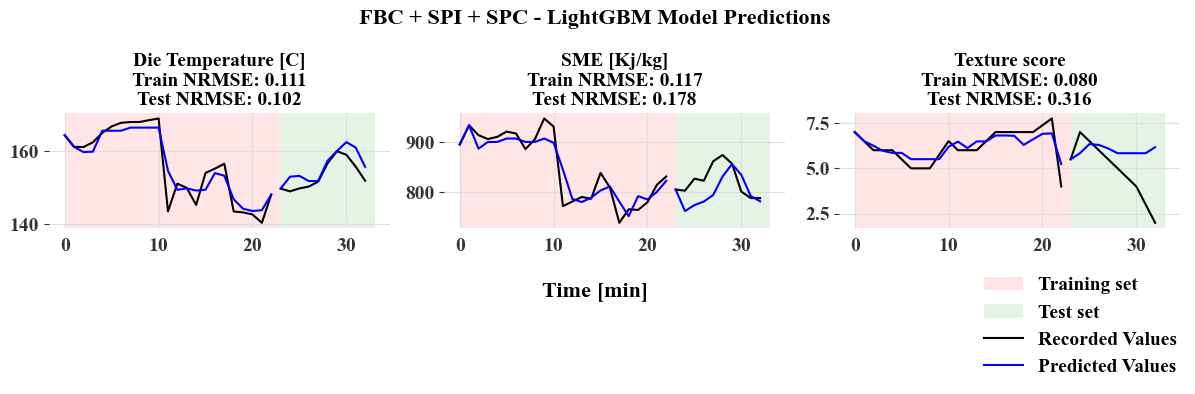

In [ ]:
# Time series plots
for model_name, model_df, pred_cols in [('XGBoost', xgb_df_g, predicted_xgb),
                                         ('LightGBM', gbm_df_g, predicted_gbm)]:
    
    for group_key in model_df['group'].unique():
        group_df = model_df[model_df['group'] == group_key].reset_index(drop=True)
        
        fig, axes = plt.subplots(1, 3, figsize=(12, 3))
        
        for i, (label, actual, pred) in enumerate(zip(labels, targets, pred_cols)):
            plot_timeseries_with_splits(axes[i], group_df, actual, pred, plt_conf)
            
            # Calculate NRMSE for train and test
            max_val, min_val = group_df[actual].max(), group_df[actual].min()
            
            train_data = group_df[group_df['split'] == 'train']
            nrmse_train = np.sqrt(mean_squared_error(train_data[actual], train_data[pred])) / (max_val - min_val)
            
            test_data = group_df[group_df['split'] == 'test']
            nrmse_test = np.sqrt(mean_squared_error(test_data[actual], test_data[pred])) / (max_val - min_val)
            
            axes[i].set_title(f"{label}\nTrain NRMSE: {nrmse_train:.3f}\nTest NRMSE: {nrmse_test:.3f}",
                             fontsize=14, fontweight='bold')
        
        fig.supxlabel('Time [min]', fontsize=plt_conf['label_fontsize'], fontweight='bold')
        fig.suptitle(f"{group_key} - {model_name} Model Predictions", fontsize=plt_conf['label_fontsize'], fontweight='bold')
        fig.legend(['Training set', 'Test set', 'Recorded Values', 'Predicted Values'],
                  prop={'weight': 'bold', 'size': plt_conf['legend_fontsize']},
                  bbox_to_anchor=(1, -0.3), loc='lower right')
        fig.tight_layout()
        plt.show()

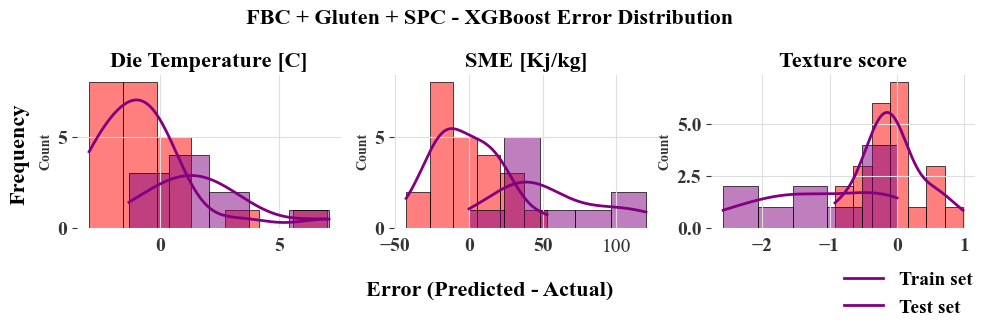

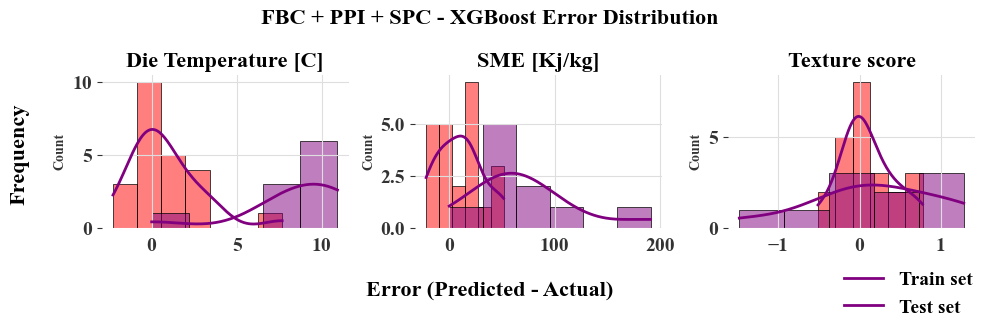

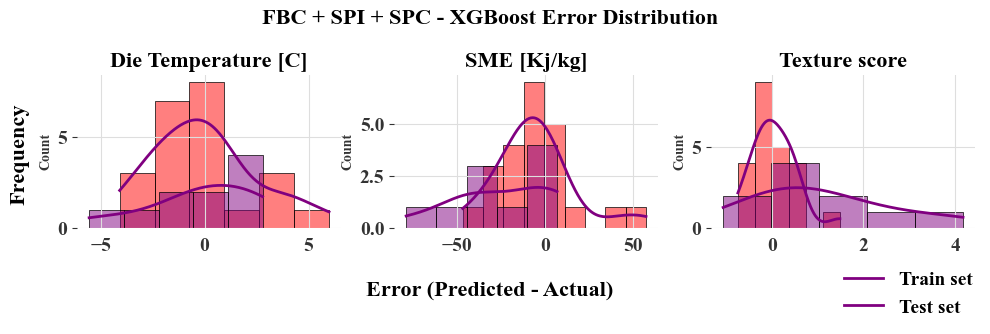

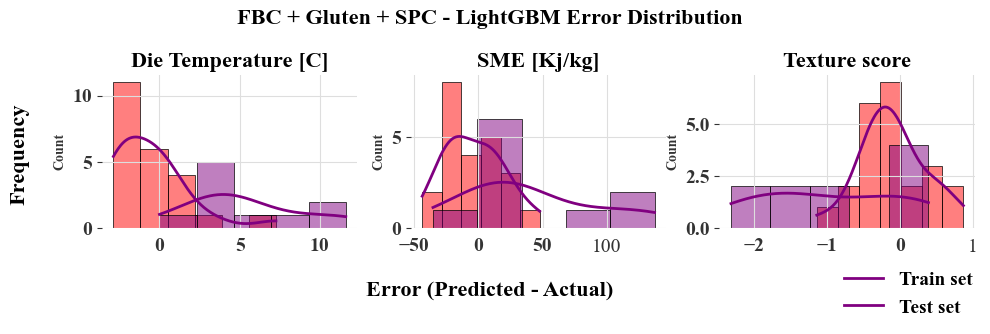

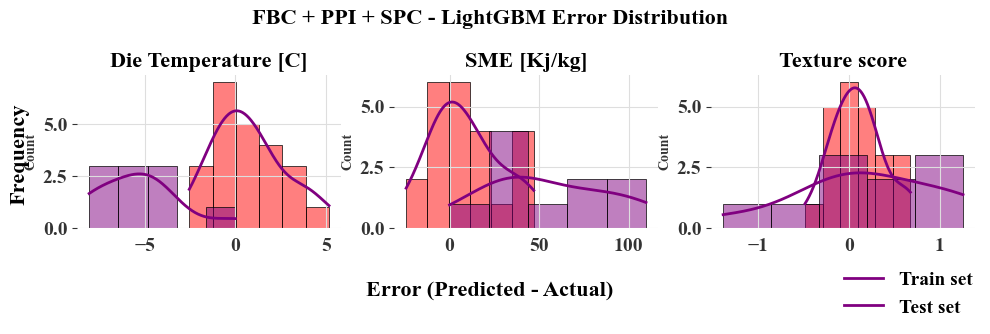

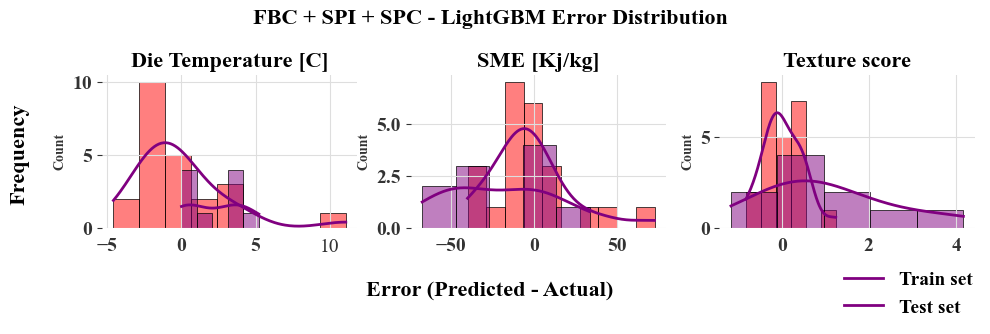

In [ ]:
# Error distribution plots (histograms of residuals)
for model_name, model_df, pred_cols in [('XGBoost', xgb_df_g, predicted_xgb),
                                         ('LightGBM', gbm_df_g, predicted_gbm)]:
    
    for group_key in model_df['group'].unique():
        group_df = model_df[model_df['group'] == group_key].reset_index(drop=True)
        
        fig, axes = plt.subplots(1, 3, figsize=(10, 3))
        
        for i, (label, actual, pred) in enumerate(zip(labels, targets, pred_cols)):
            train_data = group_df[group_df['split'] == 'train']
            test_data = group_df[group_df['split'] == 'test']
            
            plot_error_distribution(axes[i], train_data[actual].values, train_data[pred].values, 
                                   color='red', plt_conf=plt_conf)
            plot_error_distribution(axes[i], test_data[actual].values, test_data[pred].values,
                                   color='purple', plt_conf=plt_conf)
            
            axes[i].set_title(label, fontsize=plt_conf['label_fontsize'], fontweight='bold')
        
        fig.supxlabel('Error (Predicted - Actual)', fontsize=plt_conf['label_fontsize'], fontweight='bold')
        fig.supylabel('Frequency', fontsize=plt_conf['label_fontsize'], fontweight='bold')
        fig.suptitle(f"{group_key} - {model_name} Error Distribution", fontsize=plt_conf['label_fontsize'], fontweight='bold')
        fig.legend(['Train set', 'Test set'],
                  prop={'weight': 'bold', 'size': plt_conf['legend_fontsize']},
                  bbox_to_anchor=(1, -0.10), loc='lower right')
        fig.tight_layout()
        plt.show()

In [ ]:
# Metrics tables
err_dfs = {}
for model_name, model_df, pred_cols in [('XGBoost', xgb_df_g, predicted_xgb),
                                         ('Gradient Boosting', gbm_df_g, predicted_gbm)]:
    train_df = model_df[model_df['split'] == 'train']
    test_df = model_df[model_df['split'] == 'test']
    
    train_metrics = get_metrics_df(train_df, targets, pred_cols, labels, 'Train', model_df)
    test_metrics = get_metrics_df(test_df, targets, pred_cols, labels, 'Test', model_df)
    
    err_dfs[model_name] = pd.concat([train_metrics, test_metrics])

In [ ]:
display(err_dfs['XGBoost'])

,Model_name,MAE,NRMSE_range,MB,Split,data_range
0,Die Temperature [C],1.663763,0.061756,0.052451,Train,169.04 - 129.91
1,SME [Kj/kg],17.971693,0.063118,1.041549,Train,948.12 - 570.06
2,Texture score,0.315819,0.085254,0.026627,Train,9.0 - 2.0
0,Die Temperature [C],4.133201,0.186978,3.338224,Test,169.04 - 129.91
1,SME [Kj/kg],50.889206,0.216179,33.789726,Test,948.12 - 570.06
2,Texture score,1.027422,0.202976,0.066899,Test,9.0 - 2.0


In [ ]:
display(err_dfs['Gradient Boosting'])

,Model_name,MAE,NRMSE_range,MB,Split,data_range
0,Die Temperature [C],1.847659,0.068428,0.049952,Train,169.04 - 129.91
1,SME [Kj/kg],17.555471,0.063011,1.002019,Train,948.12 - 570.06
2,Texture score,0.314629,0.082430,0.009918,Train,9.0 - 2.0
0,Die Temperature [C],4.273860,0.173090,0.743320,Test,169.04 - 129.91
1,SME [Kj/kg],44.186800,0.187775,24.915327,Test,948.12 - 570.06
2,Texture score,0.996178,0.197402,0.100370,Test,9.0 - 2.0
